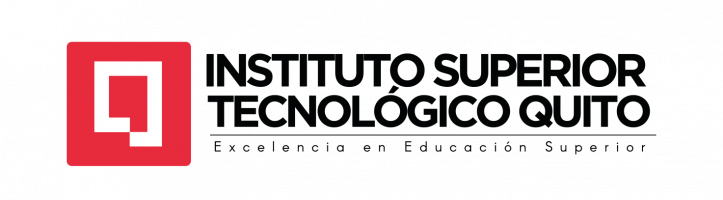

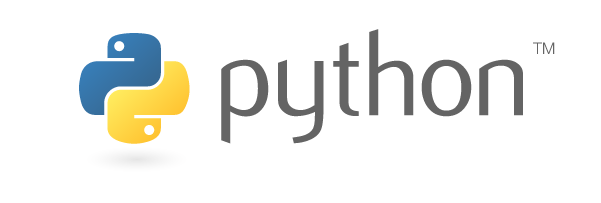

*Byron Armando Melo Aguilar*

*[Enlace a Github](https://github.com/ByronMN911/practicas-machine-learning-I/tree/main/Parcial%20III/Tarea%201)*

### SEGMENTACIÓN MEDIANTE THRESHOLDING

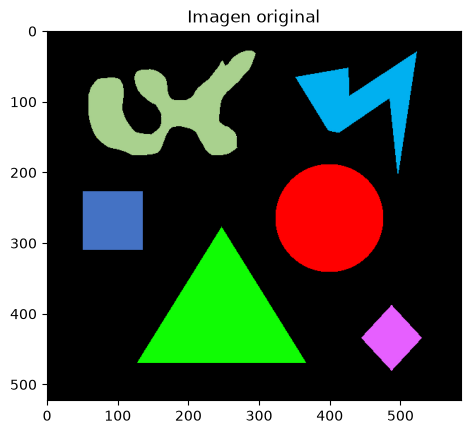

In [1]:
import matplotlib.pyplot as plt
import cv2

"""
Leemos la imagen almacenada en la carpeta "images"

OpenCV carga las imágenes utilizando el formato BGR (Blue, Green, Red),
sin embargo Matplotlib espera imágenes en formato RGB, por lo que será
necesario convertirla antes de visualizarla correctamente
"""
img = cv2.imread('images/figuras.png')

# Convertimos la imagen de BGR a RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Mostramos la imagen
plt.imshow(img_rgb, cmap='gray')

# Agregamos un título
plt.title('Imagen original')

# Visualizamos la figura
plt.show()

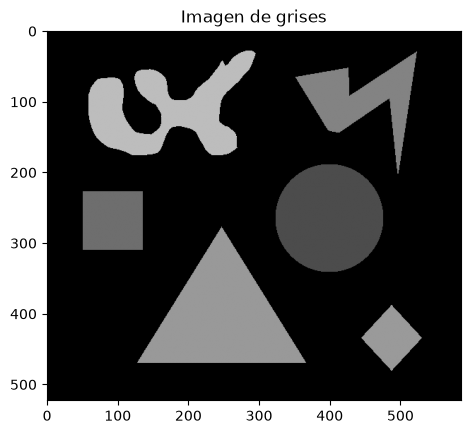

In [2]:
import numpy as np

"""
Convertimos la imagen a escala de grises

Una imagen RGB posee tres canales de color (Rojo, Verde y Azul),
mientras que una imagen en escala de grises únicamente posee un canal
que representa la intensidad de cada píxel

Trabajar en escala de grises reduce la cantidad de información que debe
procesar el algoritmo y facilita tareas como segmentación, detección de
bordes y cálculo de histogramas
"""
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# También es posible leer directamente la imagen en escala de grises
# gray_img = cv2.imread('figuras.png', 0)

# Mostramos la imagen
plt.imshow(gray_img, cmap='gray')

# Agregamos un título
plt.title('Imagen de grises')

# Visualizamos la figura
plt.show()

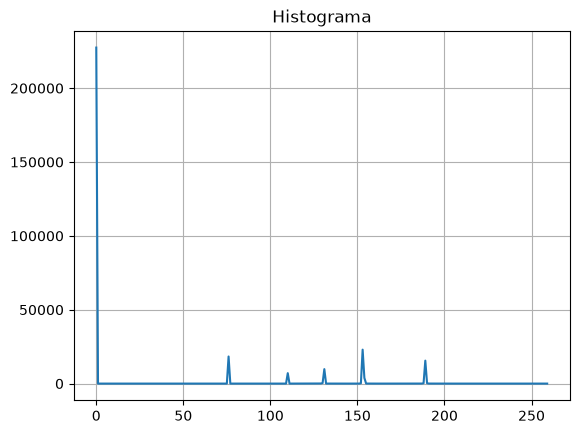

'\nOtra forma de visualizar el histograma utilizando Matplotlib\n\nravel() convierte la matriz de la imagen en un único vector con todos\nlos valores de intensidad para que puedan ser contabilizados por plt.hist()\n'

In [3]:
"""
Calculamos el histograma de la imagen

El histograma representa la cantidad de píxeles existentes para cada
nivel de intensidad

Parámetros utilizados

[gray_img]  -> Imagen sobre la que se calcula el histograma
[0]         -> Canal que se analizará, en este caso el canal de grises
None        -> No se utiliza ninguna máscara, por lo que se analiza toda la imagen
[260]       -> Número de intervalos (bins)
[0,260]     -> Rango de intensidades que serán evaluadas
"""
hist = cv2.calcHist([gray_img], [0], None, [260], [0, 260])

# Dibujamos el histograma
plt.plot(hist)

# Mostramos una cuadrícula para facilitar la lectura
plt.grid()

# Agregamos un título
plt.title('Histograma')

# Visualizamos la gráfica
plt.show()

"""
Otra forma de visualizar el histograma utilizando Matplotlib

ravel() convierte la matriz de la imagen en un único vector con todos
los valores de intensidad para que puedan ser contabilizados por plt.hist()
"""

# plt.hist(gray_img.ravel(), bins=50)
# plt.grid(True)
# plt.show()

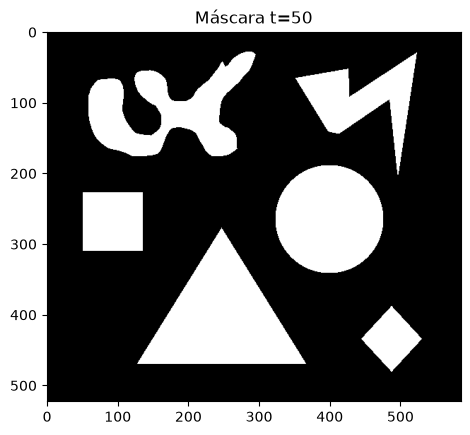

[  0 255]


In [4]:
# Definimos manualmente el valor del umbral
t = 50

# Valor máximo que tendrán los píxeles que superen el umbral (blanco)
maxim = 255

"""
Aplicamos una umbralización binaria

Si un píxel tiene una intensidad mayor que el umbral se convierte en 255
Si un píxel tiene una intensidad menor o igual al umbral se convierte en 0

La función devuelve dos valores

El primero corresponde al umbral utilizado, que en este caso no se necesita
El segundo corresponde a la máscara binaria obtenida
"""
_, mask = cv2.threshold(gray_img, t, maxim, cv2.THRESH_BINARY)

"""
Otra forma de obtener la máscara

Se copia la imagen y posteriormente se compara cada píxel con el umbral

El resultado es una matriz booleana donde

True  representa los píxeles que cumplen la condición
False representa los píxeles que no la cumplen
"""

# mask = gray_img.copy()
# mask = mask > t

# Mostramos la máscara obtenida
plt.imshow(mask, cmap='gray')

# Agregamos un título
plt.title('Máscara t=' + str(t))

# Visualizamos la imagen
plt.show()

"""
Mostramos los valores únicos presentes en la máscara

Esto permite verificar si la máscara contiene valores binarios como
0 y 255 o valores booleanos como True y False
"""
print(np.unique(mask))

[0 1]


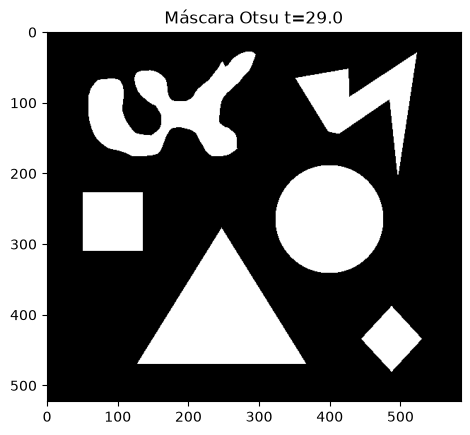

In [5]:
"""
Aplicamos el método de Otsu

Este algoritmo analiza automáticamente el histograma de la imagen para
encontrar el valor de umbral que mejor separa el objeto del fondo

No es necesario seleccionar el umbral manualmente
Es decir en el método otsu se calcula el umbral de forma automática
"""
t, mask = cv2.threshold(gray_img, 0, 1, cv2.THRESH_OTSU)

"""
Mostramos los valores únicos de la máscara

Como el valor máximo especificado es 1, la imagen binaria únicamente
contendrá los valores 0 y 1
"""
print(np.unique(mask))

# Mostramos la máscara obtenida
plt.imshow(mask, cmap='gray')

# Agregamos el valor del umbral calculado automáticamente
plt.title('Máscara Otsu t=' + str(t))

# Visualizamos la imagen
plt.show()

### SEGMENTACIÓN MEDIANTE CONVERSIONES DE COLOR

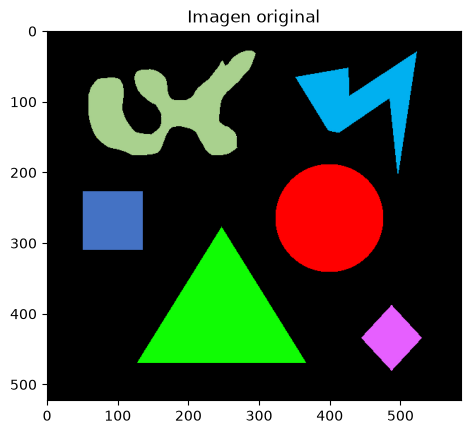

In [6]:
"""
En este ejemplo queremos segmentar únicamente el círculo utilizando
la información de color de la imagen

Leemos nuevamente la imagen y la convertimos de BGR a RGB para poder
visualizarla correctamente con Matplotlib
"""
img = cv2.imread('images/figuras.png')

# Convertimos la imagen de BGR a RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Mostramos la imagen original
plt.imshow(img_rgb, cmap='gray')

# Agregamos un título
plt.title('Imagen original')

# Visualizamos la figura
plt.show()

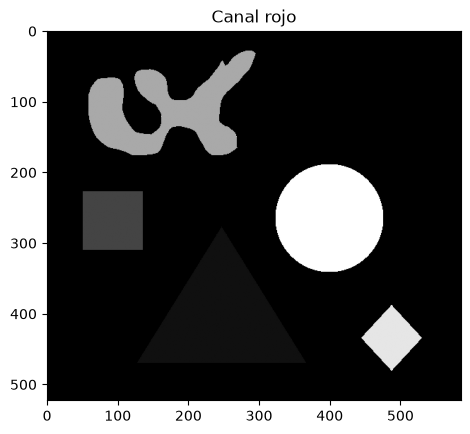

In [7]:
"""
Extraemos únicamente el canal rojo de la imagen

Una imagen RGB está formada por tres canales

Posición 0 -> Azul (B)
Posición 1 -> Verde (G)
Posición 2 -> Rojo (R)

Como la imagen fue leída con OpenCV (BGR), el canal rojo se encuentra
en la posición 2
"""
R = img[:, :, 2]

# Mostramos únicamente el canal rojo
plt.imshow(R, cmap='gray')

# Agregamos un título
plt.title('Canal rojo')

# Visualizamos la imagen
plt.show()

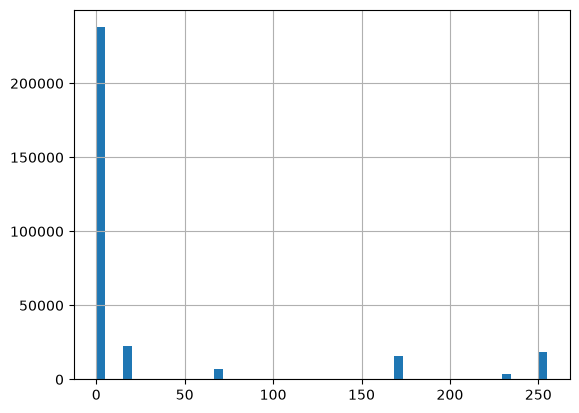

255


In [8]:
"""
Calculamos el histograma del canal rojo

ravel() convierte la matriz del canal en un único vector para que
Matplotlib pueda calcular la frecuencia de cada intensidad
"""
plt.hist(R.ravel(), bins=50)

# Mostramos una cuadrícula para facilitar la lectura
plt.grid(True)

# Visualizamos el histograma
plt.show()

"""
Mostramos la intensidad máxima presente en el canal rojo

Este valor servirá para definir el umbral durante la segmentación
"""
print(np.max(R))

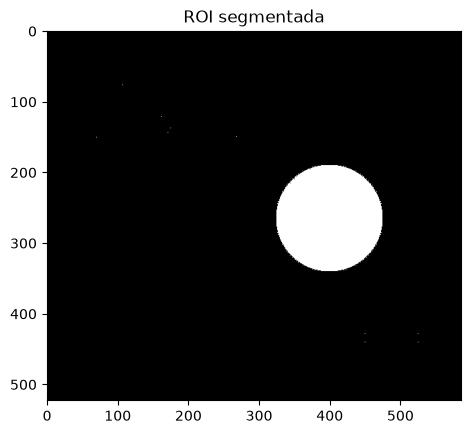

In [9]:
"""
Utilizamos como umbral la intensidad máxima encontrada en el canal rojo

De esta forma únicamente permanecerán los píxeles con el mayor nivel
de rojo presente en la imagen, el 255
"""
t = np.max(R)

# Creamos una copia del canal rojo para construir la máscara
mask = R.copy()

"""
Todos los píxeles cuya intensidad sea menor que el umbral se convierten
en 0 (lo convierte a negro), dejando únicamente los píxeles con intensidad máxima
"""
mask[mask < t] = 0

# Mostramos la máscara obtenida
plt.imshow(mask, cmap='gray')

# Agregamos un título
plt.title('ROI segmentada')

# Visualizamos la imagen
plt.show()

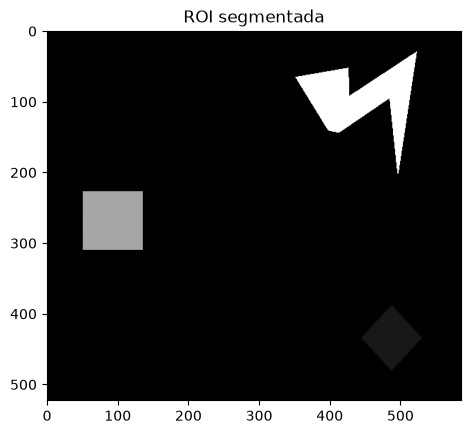

'\nExplicación del razonamiento clave del ejercicio:\n\nEn CMYK, el canal Yellow representa la ausencia de azul: cuanto más azul tiene un píxel, más bajo es su valor\nde Yellow (idealmente cercano a 0 para un azul puro)\nLas demás figuras de la imagen (verde, rojo, magenta) tienen un componente azul mucho menor, por lo que su\nvalor de Yellow es alto\nPor eso, umbralizar sobre el canal Y permite separar de forma efectiva los píxeles azules del resto de la imagen\nSe aplica el filtro sobre el canal C (Cyan) porque este canal ya tiene buen contraste en la zona azul (valores altos),\ny al anular con la condición Y > umbral se logra que solo sobreviva la región del rayo\n'

In [10]:
# Ejercicio individual
# Obtener una máscara con la imagen del rayo azul mediante segmentación por espacio de color

"""
Esta función convierte una imagen del espacio de color RGB al espacio
CMYK
El modelo CMYK utiliza cuatro canales
C -> Cyan
M -> Magenta
Y -> Yellow
K -> Black
Este espacio de color puede facilitar la segmentación de objetos cuyos
colores son difíciles de separar utilizando únicamente RGB
"""
def convert_to_CMYK(rgb_p):
    """
    np.errstate evita que Python genere advertencias cuando durante
    los cálculos ocurren divisiones entre cero o valores indefinidos
    """
    with np.errstate(invalid='ignore', divide='ignore'):
        # Calculamos el canal negro
        K = 1 - np.max(rgb_p, axis=2)
        # Calculamos el canal Cyan
        C = (1 - rgb_p[:, :, 0] - K) / (1 - K)
        # Calculamos el canal Magenta
        M = (1 - rgb_p[:, :, 1] - K) / (1 - K)
        # Calculamos el canal Yellow
        Y = (1 - rgb_p[:, :, 2] - K) / (1 - K)
        """
        dstack une los cuatro canales formando una sola imagen
        Posteriormente se multiplican por 255 para trabajar con valores
        entre 0 y 255 y finalmente se convierten al tipo uint8
        """
        CMYK = (np.dstack((C, M, Y, K)) * 255).astype('uint8')
    # Retornamos la imagen convertida al espacio CMYK
    return CMYK

# Leemos la imagen
img = cv2.imread('images/figuras.png')
# Convertimos la imagen de BGR a RGB
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

"""
Convertimos la imagen a valores entre 0 y 1
Esto facilita los cálculos matemáticos utilizados para obtener los
canales CMYK
"""
rgb_p = rgb.astype('uint8') / 255

# Convertimos la imagen al espacio de color CMYK
CMYK = convert_to_CMYK(rgb_p)

"""
Separamos los cuatro canales de la imagen CMYK
Cada variable almacenará uno de los canales por separado
"""
C, M, Y, K = CMYK[:, :, 0], CMYK[:, :, 1], CMYK[:, :, 2], CMYK[:, :, 3]

# Convertimos el canal Cyan a tipo uint8
C = C.astype('uint8')

"""
Aquí debe calcularse la máscara del rayo azul utilizando el canal que
permita diferenciar mejor esta figura del resto de la imagen

El canal elegido es el Yellow (Y), ya que el color azul del rayo no
contiene componente amarilla, por lo que su valor en este canal es
cercano a cero, mientras que el resto de figuras de la imagen (verde,
rojo, magenta) sí presentan valores altos en el canal Yellow

Aprovechamos esta diferencia para filtrar el canal Cyan: en todos los
píxeles donde el valor de Yellow sea alto (es decir, donde no hay azul)
se pone a cero el canal Cyan, dejando visible únicamente la región
correspondiente al rayo azul
"""
umbral = 30
C[Y > umbral] = 0

# Mostramos la imagen resultante
plt.imshow(C, cmap='gray')
# Agregamos un título
plt.title('ROI segmentada')
# Visualizamos la figura
plt.show()

"""
Explicación del razonamiento clave del ejercicio:

En CMYK, el canal Yellow representa la ausencia de azul: cuanto más azul tiene un píxel, más bajo es su valor
de Yellow (idealmente cercano a 0 para un azul puro)
Las demás figuras de la imagen (verde, rojo, magenta) tienen un componente azul mucho menor, por lo que su
valor de Yellow es alto
Por eso, umbralizar sobre el canal Y permite separar de forma efectiva los píxeles azules del resto de la imagen
Se aplica el filtro sobre el canal C (Cyan) porque este canal ya tiene buen contraste en la zona azul (valores altos),
y al anular con la condición Y > umbral se logra que solo sobreviva la región del rayo
"""

### SEGMENTACIÓN SEMÁNTICA CON DETECCIÓN DE BORDES

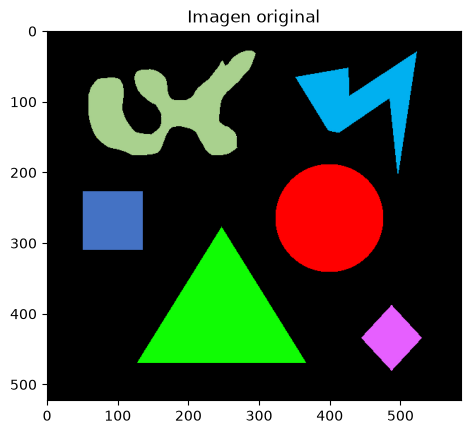

In [11]:
# SEGMENTACIÓN SEMÁNTICA CON DETECCIÓN DE BORDES

"""
Cargamos la imagen desde disco con cv2.imread
OpenCV lee las imágenes en formato BGR por defecto (no RGB)
por lo que es necesario convertir el orden de los canales
antes de visualizarla con matplotlib, que espera formato RGB
"""
img = cv2.imread('images/figuras.png')

# Convertimos de BGR (formato de OpenCV) a RGB (formato de matplotlib)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Mostramos la imagen original ya convertida a RGB
plt.imshow(img_rgb)
plt.title('Imagen original')
plt.show()

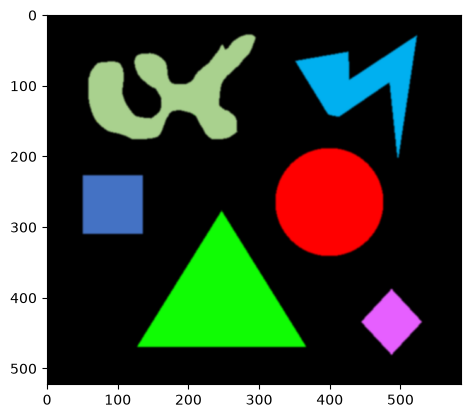

In [12]:
"""
Aplicamos un filtro gaussiano para suavizar la imagen y eliminar ruido
de alta frecuencia (detalles finos y ruido aleatorio)
Este paso es importante antes de la detección de bordes ya que el ruido
puede generar bordes falsos que no corresponden a los objetos reales
"""
# Aplicamos un filtro gaussiano para emborronar las altas frecuencias
img_gaus = cv2.GaussianBlur(img_rgb, (5,5), 0) # (5x5) es el tamaño del filtro y 0 es la desviación estándar

# Visualizamos el resultado del suavizado
plt.imshow(img_gaus, cmap='gray')
plt.show()

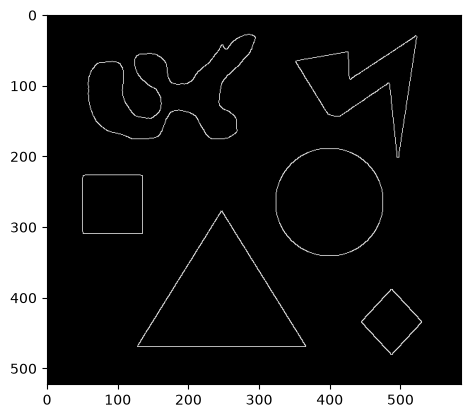

In [13]:
"""
El algoritmo de Canny detecta bordes mediante un proceso de varias etapas:
cálculo del gradiente, supresión de no máximos y umbralización con histéresis
Utiliza dos umbrales (minValue y maxValue) para clasificar los píxeles
como bordes fuertes, débiles o no bordes
"""
# Detección de bordes de Canny
canny = cv2.Canny(img_gaus, 255/3, 255) # minValue and maxValue. Canny recomienda que minValue sea 3 veces mayor que maxValue

# Definimos un kernel de 2x2 que podría usarse para operaciones morfológicas
kernel = np.ones((2,2), 'uint8')

"""
Estas líneas están comentadas pero se dejan como referencia
La dilatación (dilate) expande los bordes detectados, útil cuando
los bordes quedan discontinuos o con pequeños huecos
La erosión (erode) reduce el grosor de los bordes, útil para
eliminar ruido residual después de la dilatación
"""
#canny = cv2.dilate(canny, kernel, iterations=2)
#canny = cv2.erode(canny, kernel, iterations=2)

# Visualizamos el resultado de la detección de bordes
plt.imshow(canny, cmap='gray')
plt.show()

C:\Users\Arman\AppData\Local\Temp\ipykernel_3828\3788106082.py:8: DeprecationWarning: Please import `binary_fill_holes` from the `scipy.ndimage` namespace; the `scipy.ndimage.morphology` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.morphology import binary_fill_holes as bfh


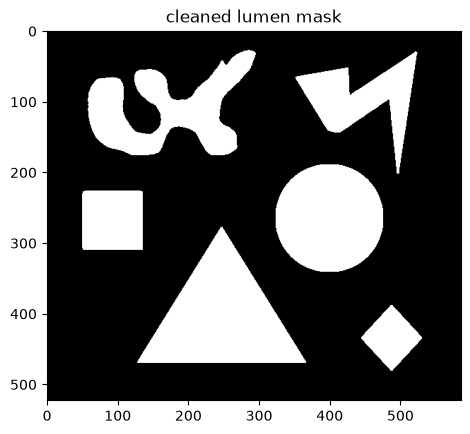

In [14]:
"""
binary_fill_holes rellena los huecos internos de una máscara binaria
Solo rellena regiones que están completamente rodeadas por bordes (True)
si una región está en contacto con el límite de la imagen no se considera
un hueco cerrado y por lo tanto no se rellena
"""
# Rellenar objetos (solo rellena si no están en contacto con el límite de la imagen)
from scipy.ndimage.morphology import binary_fill_holes as bfh

# Hacemos una copia de los bordes detectados para no modificar el original
bordes = canny.copy()

# Rellenamos los huecos cerrados dentro de los contornos
filled_bordes = bfh(bordes)

# Convertimos a uint8 para poder visualizar correctamente con matplotlib
plt.imshow(filled_bordes.astype('uint8'), cmap='gray')
plt.title('cleaned lumen mask')
plt.show()

### SEGMENTACIÓN POR CRECIMIENTO DE REGIONES (region growing)

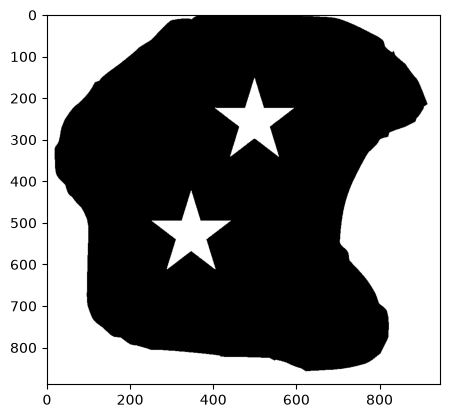

In [15]:
# Cargar imagen
from skimage import io
import cv2
import numpy as np
import matplotlib.pyplot as plt

"""
Cargamos la imagen indicando el flag 0, lo que le dice a OpenCV
que la lea directamente en escala de grises (un solo canal)
en lugar de los tres canales de color por defecto
"""
img = cv2.imread('images/estrellas.png', 0)

# Visualizamos la imagen en escala de grises
plt.imshow(img, cmap='gray')
plt.show()

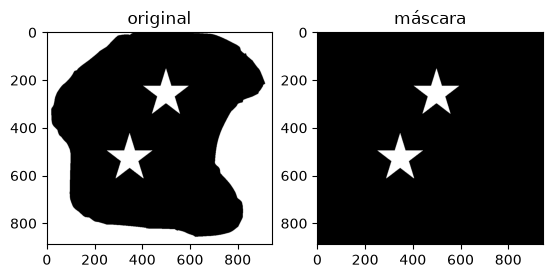

In [16]:
"""
El algoritmo floodFill de OpenCV rellena una región conectada de la imagen
a partir de un píxel semilla, propagándose mientras encuentra píxeles
de valor similar, es una técnica clásica de segmentación por crecimiento
de regiones
"""
# Crear una copia de la imagen
mask = img.copy()

# Definir una imagen negra de referencia
h, w = img.shape

"""
OpenCV exige que la máscara de referencia para floodFill tenga
un tamaño de (alto+2, ancho+2), es decir 2 píxeles más en cada
dimensión que la imagen original, esto es un requisito interno
de la función y no es opcional
"""
ref = np.zeros((h+2, w+2), np.uint8)

# Fijar la semilla. En este caso en la esquina superior izquierda (posición 0,0) para rellenar a partir de ahí
cv2.floodFill(mask, ref, (0,0), 0); # Como nos interesa rellenar de negro, utilizamos el 0 en la última posición

# Creamos una figura con dos subplots para comparar imagen original y máscara resultante
fig, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(mask, cmap='gray'), ax[1].set_title('máscara')
plt.show()